In [ ]:
!pip install fastf1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 424.7/424.7 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.7 MB/s eta 0:00:00
  Attempting uninstall: msgpack
    Found existing installation: msgpack 1.2.1
    Uninstalling msgpack-1.2.1:
      Successfully uninstalled msgpack-1.2.1


In [ ]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/F1-Race-Strategy-Simulator")
RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
CACHE_DIR = PROJECT_DIR / "fastf1_cache"
OUTPUT_DIR = PROJECT_DIR / "outputs"

for folder in [RAW_DIR, PROCESSED_DIR, CACHE_DIR, OUTPUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folder:", PROJECT_DIR)

Project folder: /content/drive/MyDrive/F1-Race-Strategy-Simulator


In [ ]:
fastf1.Cache.enable_cache(str(CACHE_DIR))

In [ ]:
import requests

url = "https://livetiming.formula1.com/static/2025/"

r = requests.get(
    url,
    headers={"User-Agent": "BestHTTP"}
)

print("Status:", r.status_code)
print("Response length:", len(r.content))

Status: 403
Response length: 919


In [ ]:
from pathlib import Path
import pandas as pd

PROJECT_DIR = Path(
    "/content/drive/MyDrive/F1-Race-Strategy-Simulator"
)

SOURCE_DIR = PROJECT_DIR / "data" / "source"

races = pd.read_csv(SOURCE_DIR / "races.csv")
drivers = pd.read_csv(SOURCE_DIR / "drivers.csv")
lap_times = pd.read_csv(SOURCE_DIR / "lap_times.csv")
tyre_laps = pd.read_csv(SOURCE_DIR / "tyre_laps.csv")

print("races:", races.shape)
print("drivers:", drivers.shape)
print("lap_times:", lap_times.shape)
print("tyre_laps:", tyre_laps.shape)

races: (1171, 18)
drivers: (865, 9)
lap_times: (877075, 6)
tyre_laps: (188482, 7)


In [ ]:
print("RACES")
print(races.columns.tolist())

print("\nDRIVERS")
print(drivers.columns.tolist())

print("\nLAP TIMES")
print(lap_times.columns.tolist())

print("\nTYRE LAPS")
print(tyre_laps.columns.tolist())

RACES
['raceId', 'year', 'round', 'circuitId', 'name', 'date', 'time', 'url', 'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time', 'quali_date', 'quali_time', 'sprint_date', 'sprint_time']

DRIVERS
['driverId', 'driverRef', 'number', 'code', 'forename', 'surname', 'dob', 'nationality', 'url']

LAP TIMES
['raceId', 'driverId', 'lap', 'position', 'time', 'milliseconds']

TYRE LAPS
['raceId', 'driverId', 'lap', 'compound', 'stint', 'tyreLife', 'driverCode']


In [ ]:
display(races.tail())
display(lap_times.head())
display(tyre_laps.head())

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
1166,1186,2026,18,32,Mexico City Grand Prix,2026-11-01,20:00:00,https://en.wikipedia.org/wiki/2026_Mexico_City...,2026-10-30,18:30:00,2026-10-30,22:00:00,2026-10-31,17:30:00,2026-10-31,21:00:00,\N,\N
1167,1187,2026,19,18,Brazilian Grand Prix,2026-11-08,17:00:00,https://en.wikipedia.org/wiki/2026_Brazilian_G...,2026-11-06,15:30:00,2026-11-06,19:00:00,2026-11-07,14:30:00,2026-11-07,18:00:00,\N,\N
1168,1188,2026,20,80,Las Vegas Grand Prix,2026-11-22,04:00:00,https://en.wikipedia.org/wiki/2026_Las_Vegas_G...,2026-11-20,00:30:00,2026-11-20,04:00:00,2026-11-21,00:30:00,2026-11-21,04:00:00,\N,\N
1169,1189,2026,21,78,Qatar Grand Prix,2026-11-29,16:00:00,https://en.wikipedia.org/wiki/2026_Qatar_Grand...,2026-11-27,13:30:00,2026-11-27,17:00:00,2026-11-28,14:30:00,2026-11-28,18:00:00,\N,\N
1170,1190,2026,22,24,Abu Dhabi Grand Prix,2026-12-06,13:00:00,https://en.wikipedia.org/wiki/2026_Abu_Dhabi_G...,2026-12-04,09:30:00,2026-12-04,13:00:00,2026-12-05,10:30:00,2026-12-05,14:00:00,\N,\N


,raceId,driverId,lap,position,time,milliseconds
0,479,137,1,1,1:42.085,102085
1,479,137,2,2,1:36.287,96287
2,479,137,3,2,1:34.627,94627
3,479,137,4,2,1:34.041,94041
4,479,137,5,2,1:33.699,93699


,raceId,driverId,lap,compound,stint,tyreLife,driverCode
0,989,1,1,UNKNOWN,NaN,NaN,HAM
1,989,1,2,UNKNOWN,NaN,NaN,HAM
2,989,1,3,ULTRASOFT,1.0,4.0,HAM
3,989,1,4,ULTRASOFT,1.0,5.0,HAM
4,989,1,5,ULTRASOFT,1.0,6.0,HAM


In [ ]:
races_2025 = races[races["year"] == 2025]

display(
    races_2025[
        ["raceId", "round", "name"]
    ]
)

,raceId,round,name
1125,1145,1,Australian Grand Prix
1126,1146,2,Chinese Grand Prix
1127,1147,3,Japanese Grand Prix
1128,1148,4,Bahrain Grand Prix
1129,1149,5,Saudi Arabian Grand Prix
1130,1150,6,Miami Grand Prix
1131,1151,7,Emilia Romagna Grand Prix
1132,1152,8,Monaco Grand Prix
1133,1153,9,Spanish Grand Prix
1134,1154,10,Canadian Grand Prix


In [ ]:
RACE_ID = 1148

bahrain_laps = lap_times[
    lap_times["raceId"] == RACE_ID
].copy()

bahrain_tyres = tyre_laps[
    tyre_laps["raceId"] == RACE_ID
].copy()

print("Lap timing rows :", len(bahrain_laps))
print("Tyre rows       :", len(bahrain_tyres))

Lap timing rows : 1128
Tyre rows       : 1128


In [ ]:
print("LAP TIMES:")
print(bahrain_laps.columns.tolist())

print("\nTYRES:")
print(bahrain_tyres.columns.tolist())

LAP TIMES:
['raceId', 'driverId', 'lap', 'position', 'time', 'milliseconds']

TYRES:
['raceId', 'driverId', 'lap', 'compound', 'stint', 'tyreLife', 'driverCode']


In [ ]:
display(bahrain_laps.head())
display(bahrain_tyres.head())

,raceId,driverId,lap,position,time,milliseconds
842192,1148,857,1,1,1:38.693,98693
842193,1148,847,1,2,1:39.582,99582
842194,1148,846,1,3,1:40.424,100424
842195,1148,844,1,4,1:41.332,101332
842196,1148,842,1,5,1:42.050,102050


,raceId,driverId,lap,compound,stint,tyreLife,driverCode
164844,1148,1,1,MEDIUM,1.0,1.0,HAM
164845,1148,1,2,MEDIUM,1.0,2.0,HAM
164846,1148,1,3,MEDIUM,1.0,3.0,HAM
164847,1148,1,4,MEDIUM,1.0,4.0,HAM
164848,1148,1,5,MEDIUM,1.0,5.0,HAM


In [ ]:
bahrain = bahrain_laps.merge(
    bahrain_tyres,
    on=["raceId", "driverId", "lap"],
    how="left"
)

print("Rows:", len(bahrain))
display(bahrain.head())

Rows: 1128


,raceId,driverId,lap,position,time,milliseconds,compound,stint,tyreLife,driverCode
0,1148,857,1,1,1:38.693,98693,SOFT,1.0,4.0,PIA
1,1148,847,1,2,1:39.582,99582,SOFT,1.0,4.0,RUS
2,1148,846,1,3,1:40.424,100424,SOFT,1.0,4.0,NOR
3,1148,844,1,4,1:41.332,101332,MEDIUM,1.0,1.0,LEC
4,1148,842,1,5,1:42.050,102050,SOFT,1.0,4.0,GAS


In [ ]:
bahrain["lapTimeSeconds"] = (
    bahrain["milliseconds"] / 1000
)

In [ ]:
columns_to_show = [
    c for c in [
        "driverCode",
        "driverId",
        "lap",
        "lapTimeSeconds",
        "position",
        "compound",
        "stint",
        "tyreLife"
    ]
    if c in bahrain.columns
]

display(
    bahrain[columns_to_show].head(30)
)

,driverCode,driverId,lap,lapTimeSeconds,position,compound,stint,tyreLife
0,PIA,857,1,98.693,1,SOFT,1.0,4.0
1,RUS,847,1,99.582,2,SOFT,1.0,4.0
2,NOR,846,1,100.424,3,SOFT,1.0,4.0
3,LEC,844,1,101.332,4,MEDIUM,1.0,1.0
4,GAS,842,1,102.050,5,SOFT,1.0,4.0
5,SAI,832,1,102.770,6,SOFT,1.0,4.0
6,ANT,863,1,103.363,7,SOFT,1.0,4.0
7,VER,830,1,103.877,8,SOFT,1.0,4.0
8,HAM,1,1,104.568,9,MEDIUM,1.0,1.0
9,TSU,852,1,104.935,10,SOFT,1.0,4.0


In [ ]:
print("Total laps:", len(bahrain))

if "compound" in bahrain.columns:
    print("\nCompound:")
    print(bahrain["compound"].value_counts(dropna=False))

if "tyreLife" in bahrain.columns:
    print(
        "\nMissing tyreLife:",
        bahrain["tyreLife"].isna().sum()
    )

if "driverCode" in bahrain.columns:
    print("\nDrivers:")
    print(bahrain["driverCode"].unique())

Total laps: 1128

Compound:
compound
MEDIUM    517
HARD      316
SOFT      295
Name: count, dtype: int64

Missing tyreLife: 0

Drivers:
['PIA' 'RUS' 'NOR' 'LEC' 'GAS' 'SAI' 'ANT' 'VER' 'HAM' 'TSU' 'DOO' 'ALO'
 'OCO' 'ALB' 'BEA' 'HAD' 'LAW' 'STR' 'BOR' 'HUL']


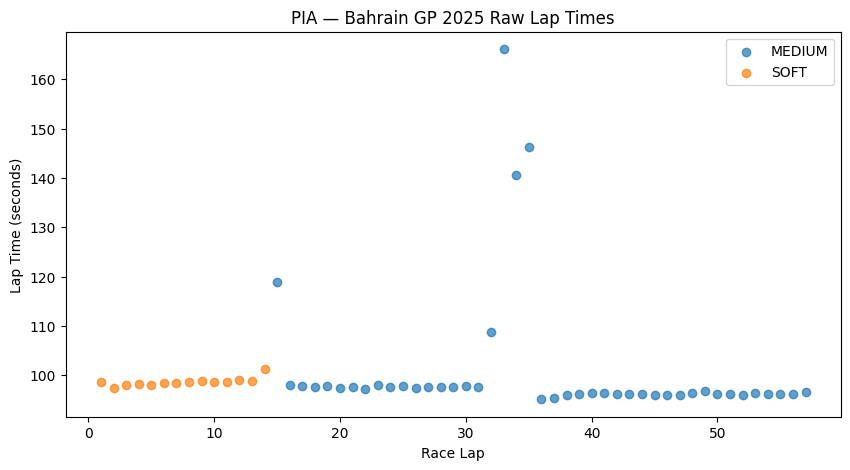

In [ ]:
import matplotlib.pyplot as plt

driver = "PIA"

d = bahrain[
    bahrain["driverCode"] == driver
].copy()

plt.figure(figsize=(10, 5))

for compound, group in d.groupby("compound"):
    plt.scatter(
        group["lap"],
        group["lapTimeSeconds"],
        label=compound,
        alpha=0.7
    )

plt.xlabel("Race Lap")
plt.ylabel("Lap Time (seconds)")
plt.title(f"{driver} — Bahrain GP 2025 Raw Lap Times")
plt.legend()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

clean = bahrain.copy()

print("Starting rows:", len(clean))

Starting rows: 1128


In [ ]:
before = len(clean)

clean = clean[
    clean["lapTimeSeconds"].notna() &
    clean["compound"].isin(["SOFT", "MEDIUM", "HARD"]) &
    clean["tyreLife"].notna()
].copy()

print("Removed missing/non-slick:", before - len(clean))
print("Remaining:", len(clean))

Removed missing/non-slick: 0
Remaining: 1128


In [ ]:
before = len(clean)

clean = clean[
    clean["lap"] > 1
].copy()

print("Removed lap 1:", before - len(clean))

Removed lap 1: 20


In [ ]:
before = len(clean)

clean = clean[
    clean["tyreLife"] > 0
].copy()

print("Removed invalid tyre life:", before - len(clean))

Removed invalid tyre life: 0


In [ ]:
clean = clean.sort_values(
    ["driverId", "lap"]
).copy()

clean["new_stint"] = (
    clean
    .groupby("driverId")["stint"]
    .diff()
    .fillna(0)
    .ne(0)
)

clean["before_new_stint"] = (
    clean
    .groupby("driverId")["new_stint"]
    .shift(-1)
    .fillna(False)
    .astype(bool)
)

clean["pit_adjacent"] = (
    clean["new_stint"] |
    clean["before_new_stint"]
)

/tmp/ipykernel_3057/3087590144.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


In [ ]:
display(
    clean[
        clean["pit_adjacent"]
    ][
        [
            "driverCode",
            "lap",
            "stint",
            "compound",
            "tyreLife",
            "lapTimeSeconds"
        ]
    ].head(30)
)

,driverCode,lap,stint,compound,tyreLife,lapTimeSeconds
321,HAM,17,1.0,MEDIUM,17.0,101.684
350,HAM,18,2.0,MEDIUM,1.0,117.887
624,HAM,32,2.0,MEDIUM,15.0,115.663
644,HAM,33,3.0,HARD,1.0,152.194
311,ALO,16,1.0,MEDIUM,16.0,103.567
338,ALO,17,2.0,MEDIUM,1.0,118.289
633,ALO,32,2.0,MEDIUM,16.0,126.361
654,ALO,33,3.0,HARD,1.0,151.707
99,HUL,5,1.0,SOFT,5.0,101.958
119,HUL,6,2.0,MEDIUM,1.0,117.624


In [ ]:
before = len(clean)

clean = clean[
    ~clean["pit_adjacent"]
].copy()

print(
    "Removed pit-adjacent laps:",
    before - len(clean)
)

print("Remaining:", len(clean))

Removed pit-adjacent laps: 84
Remaining: 1024


In [ ]:
group_cols = [
    "driverId",
    "stint"
]

clean["stint_median"] = (
    clean
    .groupby(group_cols)["lapTimeSeconds"]
    .transform("median")
)

clean["abs_deviation"] = (
    clean["lapTimeSeconds"] -
    clean["stint_median"]
).abs()

clean["stint_mad"] = (
    clean
    .groupby(group_cols)["abs_deviation"]
    .transform("median")
)

clean["robust_sigma"] = (
    1.4826 * clean["stint_mad"]
)

In [ ]:
clean["slow_threshold"] = np.maximum(
    4 * clean["robust_sigma"],
    4.0
)

clean["slow_outlier"] = (
    clean["lapTimeSeconds"] -
    clean["stint_median"]
) > clean["slow_threshold"]

In [ ]:
outliers = clean[
    clean["slow_outlier"]
].copy()

display(
    outliers[
        [
            "driverCode",
            "lap",
            "lapTimeSeconds",
            "compound",
            "tyreLife",
            "stint",
            "stint_median"
        ]
    ].sort_values(
        "lapTimeSeconds",
        ascending=False
    )
)

,driverCode,lap,lapTimeSeconds,compound,tyreLife,stint,stint_median
680,PIA,35,146.233,MEDIUM,3.0,3.0,96.2460
682,LEC,35,145.578,HARD,3.0,3.0,96.9240
681,RUS,35,145.529,SOFT,6.0,3.0,96.8155
683,NOR,35,144.498,MEDIUM,3.0,3.0,96.6655
684,HAM,35,143.064,HARD,3.0,3.0,97.3560
685,GAS,35,141.833,HARD,7.0,3.0,97.6790
660,PIA,34,140.563,MEDIUM,2.0,3.0,96.2460
661,RUS,34,140.520,SOFT,5.0,3.0,96.8155
686,OCO,35,140.271,HARD,8.0,3.0,97.9550
662,LEC,34,139.711,HARD,2.0,3.0,96.9240


In [ ]:
before = len(clean)

clean = clean[
    ~clean["slow_outlier"]
].copy()

print(
    "Removed slow outliers:",
    before - len(clean)
)

print(
    "Remaining:",
    len(clean)
)

Removed slow outliers: 52
Remaining: 972


In [ ]:
clean["stint_length"] = (
    clean
    .groupby(
        ["driverId", "stint"]
    )["lap"]
    .transform("size")
)

before = len(clean)

clean = clean[
    clean["stint_length"] >= 4
].copy()

print(
    "Removed short stints:",
    before - len(clean)
)

print(
    "Final model laps:",
    len(clean)
)

Removed short stints: 6
Final model laps: 966


In [ ]:
display(
    clean[
        [
            "driverCode",
            "lap",
            "lapTimeSeconds",
            "compound",
            "tyreLife",
            "stint"
        ]
    ].head(30)
)

,driverCode,lap,lapTimeSeconds,compound,tyreLife,stint
28,HAM,2,98.566,MEDIUM,2.0,1.0
48,HAM,3,98.419,MEDIUM,3.0,1.0
68,HAM,4,98.654,MEDIUM,4.0,1.0
88,HAM,5,99.465,MEDIUM,5.0,1.0
108,HAM,6,99.104,MEDIUM,6.0,1.0
128,HAM,7,99.279,MEDIUM,7.0,1.0
148,HAM,8,99.743,MEDIUM,8.0,1.0
167,HAM,9,100.945,MEDIUM,9.0,1.0
187,HAM,10,99.297,MEDIUM,10.0,1.0
204,HAM,11,99.146,MEDIUM,11.0,1.0


In [ ]:
print("=" * 45)
print("BAHRAIN GP 2025 — CLEANING SUMMARY")
print("=" * 45)

print("Raw laps:          ", len(bahrain))
print("Final clean laps:  ", len(clean))
print(
    "Retention:         ",
    f"{len(clean) / len(bahrain) * 100:.1f}%"
)

BAHRAIN GP 2025 — CLEANING SUMMARY
Raw laps:           1128
Final clean laps:   966
Retention:          85.6%


In [ ]:
stint_summary = (
    clean
    .groupby(
        [
            "driverCode",
            "stint",
            "compound"
        ]
    )
    .agg(
        n_laps=("lap", "size"),
        start_lap=("lap", "min"),
        end_lap=("lap", "max"),
        tyre_age_start=("tyreLife", "min"),
        tyre_age_end=("tyreLife", "max"),
        median_lap_time=("lapTimeSeconds", "median")
    )
    .reset_index()
)

display(stint_summary)

,driverCode,stint,compound,n_laps,start_lap,end_lap,tyre_age_start,tyre_age_end,median_lap_time
0,ALB,1.0,SOFT,14,2,15,2.0,15.0,99.8320
1,ALB,2.0,HARD,14,18,31,2.0,15.0,98.3415
2,ALB,3.0,MEDIUM,22,36,57,4.0,25.0,97.8365
3,ALO,1.0,MEDIUM,14,2,15,2.0,15.0,100.1060
4,ALO,2.0,MEDIUM,14,18,31,2.0,15.0,98.6140
5,ALO,3.0,HARD,22,36,57,4.0,25.0,98.4860
6,ANT,1.0,SOFT,10,2,11,5.0,14.0,98.7695
7,ANT,2.0,MEDIUM,13,14,26,2.0,14.0,98.7440
8,ANT,4.0,SOFT,22,36,57,7.0,28.0,97.7390
9,BEA,1.0,SOFT,12,2,13,2.0,13.0,99.7450


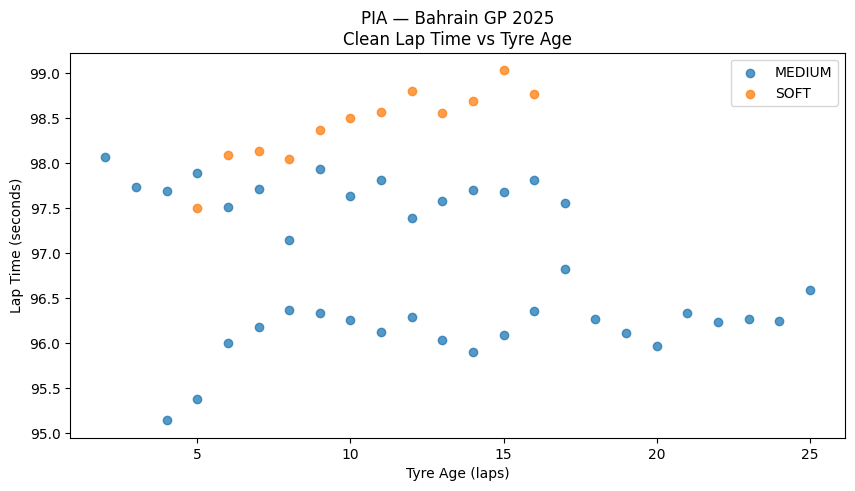

In [ ]:
driver = "PIA"

d = clean[
    clean["driverCode"] == driver
]

plt.figure(figsize=(10, 5))

for compound, group in d.groupby("compound"):
    plt.scatter(
        group["tyreLife"],
        group["lapTimeSeconds"],
        label=compound,
        alpha=0.75
    )

plt.xlabel("Tyre Age (laps)")
plt.ylabel("Lap Time (seconds)")
plt.title(
    f"{driver} — Bahrain GP 2025\n"
    "Clean Lap Time vs Tyre Age"
)

plt.legend()
plt.show()

In [ ]:
pia = clean[
    clean["driverCode"] == "PIA"
].copy()

pia_stints = (
    pia
    .groupby(["stint", "compound"])
    .agg(
        n_laps=("lap", "size"),
        race_lap_start=("lap", "min"),
        race_lap_end=("lap", "max"),
        tyre_age_start=("tyreLife", "min"),
        tyre_age_end=("tyreLife", "max"),
        median_lap_time=("lapTimeSeconds", "median")
    )
    .reset_index()
)

display(pia_stints)

,stint,compound,n_laps,race_lap_start,race_lap_end,tyre_age_start,tyre_age_end,median_lap_time
0,1.0,SOFT,12,2,13,5.0,16.0,98.5235
1,2.0,MEDIUM,16,16,31,2.0,17.0,97.6905
2,3.0,MEDIUM,22,36,57,4.0,25.0,96.2360


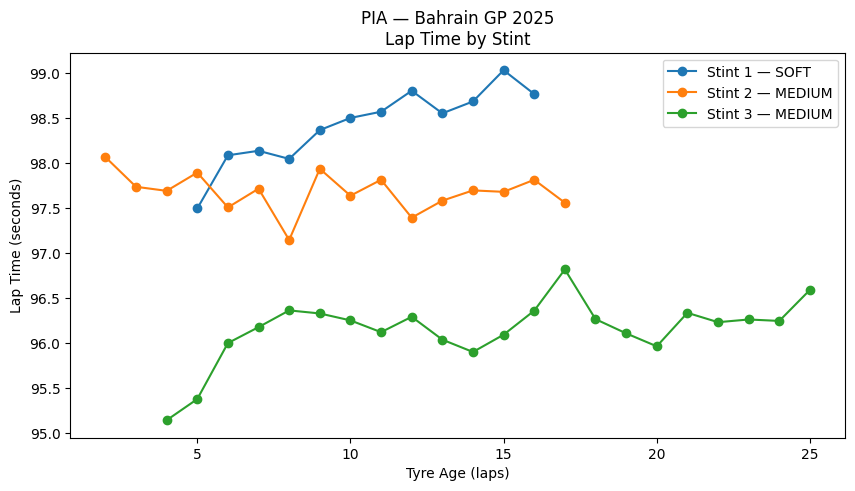

In [ ]:
plt.figure(figsize=(10, 5))

for stint, group in pia.groupby("stint"):

    compound = group["compound"].iloc[0]

    group = group.sort_values("tyreLife")

    plt.plot(
        group["tyreLife"],
        group["lapTimeSeconds"],
        marker="o",
        label=f"Stint {int(stint)} — {compound}"
    )

plt.xlabel("Tyre Age (laps)")
plt.ylabel("Lap Time (seconds)")
plt.title("PIA — Bahrain GP 2025\nLap Time by Stint")
plt.legend()
plt.show()

In [ ]:
import statsmodels.formula.api as smf

In [ ]:
model_data = clean.copy()

model_data["lap"] = pd.to_numeric(
    model_data["lap"],
    errors="coerce"
)

model_data["tyreLife"] = pd.to_numeric(
    model_data["tyreLife"],
    errors="coerce"
)

model_data["lapTimeSeconds"] = pd.to_numeric(
    model_data["lapTimeSeconds"],
    errors="coerce"
)

model_data = model_data.dropna(
    subset=[
        "lap",
        "tyreLife",
        "lapTimeSeconds",
        "compound",
        "driverCode"
    ]
)

In [ ]:
model_data["raceLapCentered"] = (
    model_data["lap"] -
    model_data["lap"].mean()
)

model_data["tyreAgeCentered"] = (
    model_data["tyreLife"] -
    model_data["tyreLife"].mean()
)

In [ ]:
model1 = smf.ols(
    formula="""
    lapTimeSeconds
    ~ raceLapCentered
    + tyreAgeCentered
    + C(compound)
    + C(driverCode)
    """,
    data=model_data
).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:         lapTimeSeconds   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.735
Method:                 Least Squares   F-statistic:                     117.7
Date:                Sat, 29 Aug 2026   Prob (F-statistic):          5.31e-258
Time:                        08:37:41   Log-Likelihood:                -755.64
No. Observations:                 966   AIC:                             1559.
Df Residuals:                     942   BIC:                             1676.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                98.89

In [ ]:
model2 = smf.ols(
    formula="""
    lapTimeSeconds
    ~ raceLapCentered
    + tyreAgeCentered * C(compound)
    + C(driverCode)
    """,
    data=model_data
).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:         lapTimeSeconds   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.737
Method:                 Least Squares   F-statistic:                     109.0
Date:                Sat, 29 Aug 2026   Prob (F-statistic):          2.44e-257
Time:                        08:41:17   Log-Likelihood:                -752.28
No. Observations:                 966   AIC:                             1557.
Df Residuals:                     940   BIC:                             1683.
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [ ]:
params = model2.params

deg_hard = params["tyreAgeCentered"]

deg_medium = (
    deg_hard +
    params.get(
        "tyreAgeCentered:C(compound)[T.MEDIUM]",
        0
    )
)

deg_soft = (
    deg_hard +
    params.get(
        "tyreAgeCentered:C(compound)[T.SOFT]",
        0
    )
)

print("Estimated degradation rates")
print("----------------------------")
print(f"HARD   : {deg_hard:.4f} s/lap")
print(f"MEDIUM : {deg_medium:.4f} s/lap")
print(f"SOFT   : {deg_soft:.4f} s/lap")

Estimated degradation rates
----------------------------
HARD   : 0.1156 s/lap
MEDIUM : 0.1043 s/lap
SOFT   : 0.1216 s/lap


In [ ]:
residual_sigma = np.sqrt(model2.mse_resid)

print(
    f"Residual lap-time sigma: "
    f"{residual_sigma:.4f} s"
)

Residual lap-time sigma: 0.5344 s


In [ ]:
race_progression = model2.params["raceLapCentered"]

compound_deg = {
    "HARD": deg_hard,
    "MEDIUM": deg_medium,
    "SOFT": deg_soft
}

compound_offset = {
    "HARD": 0.0,
    "MEDIUM": model2.params["C(compound)[T.MEDIUM]"],
    "SOFT": model2.params["C(compound)[T.SOFT]"]
}

print("Race progression effect:")
print(f"{race_progression:.4f} s/lap")

print("\nCompound pace offsets:")
for compound, value in compound_offset.items():
    print(f"{compound:<7}: {value:+.4f} s")

print("\nCompound degradation:")
for compound, value in compound_deg.items():
    print(f"{compound:<7}: {value:.4f} s/lap")

print("\nNoise:")
print(f"sigma   : {residual_sigma:.4f} s")

Race progression effect:
-0.0626 s/lap

Compound pace offsets:
HARD   : +0.0000 s
MEDIUM : -0.1309 s
SOFT   : -0.2093 s

Compound degradation:
HARD   : 0.1156 s/lap
MEDIUM : 0.1043 s/lap
SOFT   : 0.1216 s/lap

Noise:
sigma   : 0.5344 s


In [ ]:
def simulate_lap_time(
    base_pace,
    race_lap,
    tyre_age,
    compound,
    sigma=residual_sigma,
    stochastic=True
):
    # Race progression / fuel proxy
    race_effect = (
        race_progression *
        (race_lap - model_data["lap"].mean())
    )

    # Tyre degradation
    tyre_effect = (
        compound_deg[compound] *
        (tyre_age - model_data["tyreLife"].mean())
    )

    # Compound pace advantage
    compound_effect = compound_offset[compound]

    predicted = (
        base_pace
        + race_effect
        + tyre_effect
        + compound_effect
    )

    if stochastic:
        predicted += np.random.normal(
            0,
            sigma
        )

    return predicted

In [ ]:
BASE_PACE = model2.params["Intercept"]
for age in [1, 5, 10, 15, 20]:
    time = simulate_lap_time(
        base_pace=BASE_PACE,
        race_lap=25,
        tyre_age=age,
        compound="MEDIUM",
        stochastic=False
    )

    print(
        f"Medium age {age:2d}: "
        f"{time:.3f} s"
    )

Medium age  1: 97.908 s
Medium age  5: 98.325 s
Medium age 10: 98.847 s
Medium age 15: 99.369 s
Medium age 20: 99.890 s


In [ ]:
def simulate_stint(
    start_lap,
    stint_length,
    compound,
    base_pace=BASE_PACE,
    stochastic=True
):
    lap_times = []

    for i in range(stint_length):

        race_lap = start_lap + i
        tyre_age = i + 1

        lap_time = simulate_lap_time(
            base_pace=base_pace,
            race_lap=race_lap,
            tyre_age=tyre_age,
            compound=compound,
            stochastic=stochastic
        )

        lap_times.append(lap_time)

    return lap_times

In [ ]:
test_stint = simulate_stint(
    start_lap=1,
    stint_length=15,
    compound="SOFT",
    stochastic=False
)

print("Stint time:", sum(test_stint))
print(test_stint)

Stint time: 1493.2550348034492
[np.float64(99.13712702038522), np.float64(99.19615682512494), np.float64(99.25518662986467), np.float64(99.31421643460439), np.float64(99.37324623934411), np.float64(99.43227604408384), np.float64(99.49130584882356), np.float64(99.55033565356328), np.float64(99.609365458303), np.float64(99.66839526304273), np.float64(99.72742506778245), np.float64(99.78645487252217), np.float64(99.8454846772619), np.float64(99.90451448200162), np.float64(99.96354428674134)]


In [ ]:
print("Stint time:", round(float(sum(test_stint)), 3))

print([
    round(float(x), 3)
    for x in test_stint
])

Stint time: 1493.255
[99.137, 99.196, 99.255, 99.314, 99.373, 99.432, 99.491, 99.55, 99.609, 99.668, 99.727, 99.786, 99.845, 99.905, 99.964]


In [ ]:
RACE_LAPS = 57

def simulate_strategy(
    strategy,
    pit_loss=22.0,
    base_pace=BASE_PACE,
    stochastic=True
):
    """
    strategy example:
    [
        ("SOFT", 15),
        ("MEDIUM", 20),
        ("HARD", 22)
    ]
    """

    race_times = []
    current_lap = 1

    for stint_index, (compound, stint_length) in enumerate(strategy):

        stint_times = simulate_stint(
            start_lap=current_lap,
            stint_length=stint_length,
            compound=compound,
            base_pace=base_pace,
            stochastic=stochastic
        )

        race_times.extend(stint_times)

        current_lap += stint_length

        # Add pit loss after every stint except last
        if stint_index < len(strategy) - 1:
            race_times.append(pit_loss)

    return sum(race_times)

In [ ]:
strategy_A = [
    ("SOFT", 15),
    ("MEDIUM", 20),
    ("HARD", 22)
]

strategy_B = [
    ("MEDIUM", 20),
    ("HARD", 22),
    ("SOFT", 15)
]

In [ ]:
time_A = simulate_strategy(
    strategy_A,
    stochastic=False
)

time_B = simulate_strategy(
    strategy_B,
    stochastic=False
)

print(f"Strategy A: {time_A:.3f} s")
print(f"Strategy B: {time_B:.3f} s")

print(
    f"Difference: "
    f"{abs(time_A - time_B):.3f} s"
)

Strategy A: 5665.782 s
Strategy B: 5665.782 s
Difference: 0.000 s


In [ ]:
N_SIMULATIONS = 10_000

results_A = []
results_B = []

np.random.seed(42)

for _ in range(N_SIMULATIONS):

    results_A.append(
        simulate_strategy(
            strategy_A,
            stochastic=True
        )
    )

    results_B.append(
        simulate_strategy(
            strategy_B,
            stochastic=True
        )
    )

results_A = np.array(results_A)
results_B = np.array(results_B)

In [ ]:
prob_A_faster = np.mean(
    results_A < results_B
)

prob_B_faster = np.mean(
    results_B < results_A
)

print(
    f"Strategy A faster: "
    f"{prob_A_faster * 100:.1f}%"
)

print(
    f"Strategy B faster: "
    f"{prob_B_faster * 100:.1f}%"
)

print()

print(
    f"Strategy A median: "
    f"{np.median(results_A):.2f} s"
)

print(
    f"Strategy B median: "
    f"{np.median(results_B):.2f} s"
)

Strategy A faster: 50.4%
Strategy B faster: 49.6%

Strategy A median: 5665.75 s
Strategy B median: 5665.75 s


In [ ]:
strategy_A = [
    ("SOFT", 14),
    ("MEDIUM", 18),
    ("HARD", 25)
]

strategy_B = [
    ("MEDIUM", 20),
    ("HARD", 22),
    ("SOFT", 15)
]

In [ ]:
time_A = simulate_strategy(
    strategy_A,
    stochastic=False
)

time_B = simulate_strategy(
    strategy_B,
    stochastic=False
)

print(f"Strategy A: {time_A:.3f} s")
print(f"Strategy B: {time_B:.3f} s")
print(f"A - B: {time_A - time_B:+.3f} s")

Strategy A: 5668.481 s
Strategy B: 5665.782 s
A - B: +2.699 s


In [ ]:
def monte_carlo_compare(
    strategy_A,
    strategy_B,
    n_simulations=10_000
):
    results_A = np.zeros(n_simulations)
    results_B = np.zeros(n_simulations)

    for i in range(n_simulations):
        results_A[i] = simulate_strategy(
            strategy_A,
            stochastic=True
        )

        results_B[i] = simulate_strategy(
            strategy_B,
            stochastic=True
        )

    difference = results_A - results_B

    print(
        f"Strategy A faster: "
        f"{np.mean(difference < 0) * 100:.1f}%"
    )

    print(
        f"Strategy B faster: "
        f"{np.mean(difference > 0) * 100:.1f}%"
    )

    print()
    print(
        f"Median A: "
        f"{np.median(results_A):.2f} s"
    )

    print(
        f"Median B: "
        f"{np.median(results_B):.2f} s"
    )

    print(
        f"Median A-B difference: "
        f"{np.median(difference):+.2f} s"
    )

    return results_A, results_B, difference

In [ ]:
results_A, results_B, difference = monte_carlo_compare(
    strategy_A,
    strategy_B
)

Strategy A faster: 31.6%
Strategy B faster: 68.4%

Median A: 5668.49 s
Median B: 5665.81 s
Median A-B difference: +2.73 s


In [ ]:
print(difference[:10])

[ 0.58443482  3.82324671 -1.14979728 -2.00056207 -6.36027165 -1.15381668
 -8.45766474  0.84242847  2.37872047 10.40656913]


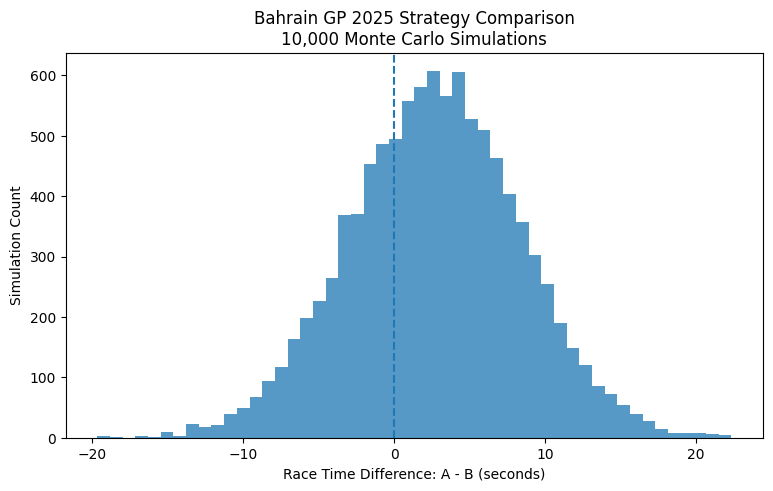

In [ ]:
plt.figure(figsize=(9, 5))

plt.hist(
    difference,
    bins=50,
    alpha=0.75
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Race Time Difference: A - B (seconds)")
plt.ylabel("Simulation Count")
plt.title(
    "Bahrain GP 2025 Strategy Comparison\n"
    "10,000 Monte Carlo Simulations"
)

plt.show()

In [ ]:
print("=" * 45)
print("MONTE CARLO STRATEGY RESULTS")
print("=" * 45)

print(
    f"Strategy A faster: "
    f"{np.mean(difference < 0) * 100:.1f}%"
)

print(
    f"Strategy B faster: "
    f"{np.mean(difference > 0) * 100:.1f}%"
)

print(
    f"Median A-B difference: "
    f"{np.median(difference):+.2f} s"
)

print(
    f"Mean A-B difference: "
    f"{np.mean(difference):+.2f} s"
)

print(
    "90% simulation interval: "
    f"{np.percentile(difference, 5):+.2f} "
    f"to "
    f"{np.percentile(difference, 95):+.2f} s"
)

MONTE CARLO STRATEGY RESULTS
Strategy A faster: 31.6%
Strategy B faster: 68.4%
Median A-B difference: +2.73 s
Mean A-B difference: +2.66 s
90% simulation interval: -6.77 to +11.95 s


In [ ]:
mc_summary = pd.DataFrame({
    "metric": [
        "Simulations",
        "Strategy A win probability",
        "Strategy B win probability",
        "Median A-B difference (s)",
        "Mean A-B difference (s)",
        "5th percentile difference (s)",
        "95th percentile difference (s)"
    ],
    "value": [
        len(difference),
        np.mean(difference < 0),
        np.mean(difference > 0),
        np.median(difference),
        np.mean(difference),
        np.percentile(difference, 5),
        np.percentile(difference, 95)
    ]
})

display(mc_summary)

,metric,value
0,Simulations,10000.000000
1,Strategy A win probability,0.315600
2,Strategy B win probability,0.684400
3,Median A-B difference (s),2.734963
4,Mean A-B difference (s),2.663623
5,5th percentile difference (s),-6.766785
6,95th percentile difference (s),11.953395


In [ ]:
SIM_DIR = OUTPUT_DIR / "simulations"
SIM_DIR.mkdir(parents=True, exist_ok=True)

mc_summary.to_csv(
    SIM_DIR / "bahrain_2025_strategy_comparison.csv",
    index=False
)

print("Monte Carlo results saved.")

Monte Carlo results saved.
